# Compiled loops with lax.scan

CPU companion; no accelerator is required. TPU execution not validated.

- Separate carry from recorded outputs
- Keep the carry contract invariant
- Differentiate the recurrence by hand
- Compile the repeated transition without a timing promise

Suppose a simulator keeps part of its current value and adds a new input at each step. Let’s write out four steps so we know what should happen. Then we’ll express the same loop with scan, compare it with Python, and see how changing the retained fraction affects the final value.

## The idea

A scan separates the state carried between steps from the outputs collected at each step. This is useful whenever the same rule repeats over time while the state keeps a fixed structure, shape and dtype.

## Unroll three steps before compiling the loop

For a separate hand-worked recurrence, start with carry $0$ and inputs $[1,2,3]$. Let each step add its input to the carry and emit the new carry. The successive carries are $1,3,6$; the final carry is $6$, while the stacked outputs are $[1,3,6]$.

Those two returned objects answer different questions. Keeping only the final carry discards the intermediate outputs. Keeping outputs does not mean the carry itself grows on each iteration. A fixed carry contract is what makes the repeated computation structured.

Trace one horizontal state edge and one downward output edge in the diagram. When adapting a Python loop, write down which variables belong on each edge before translating the loop to `lax.scan`.

### Carry moves through time; outputs are collected

**Predict:** What changes if the step emits the old carry instead of the new carry?

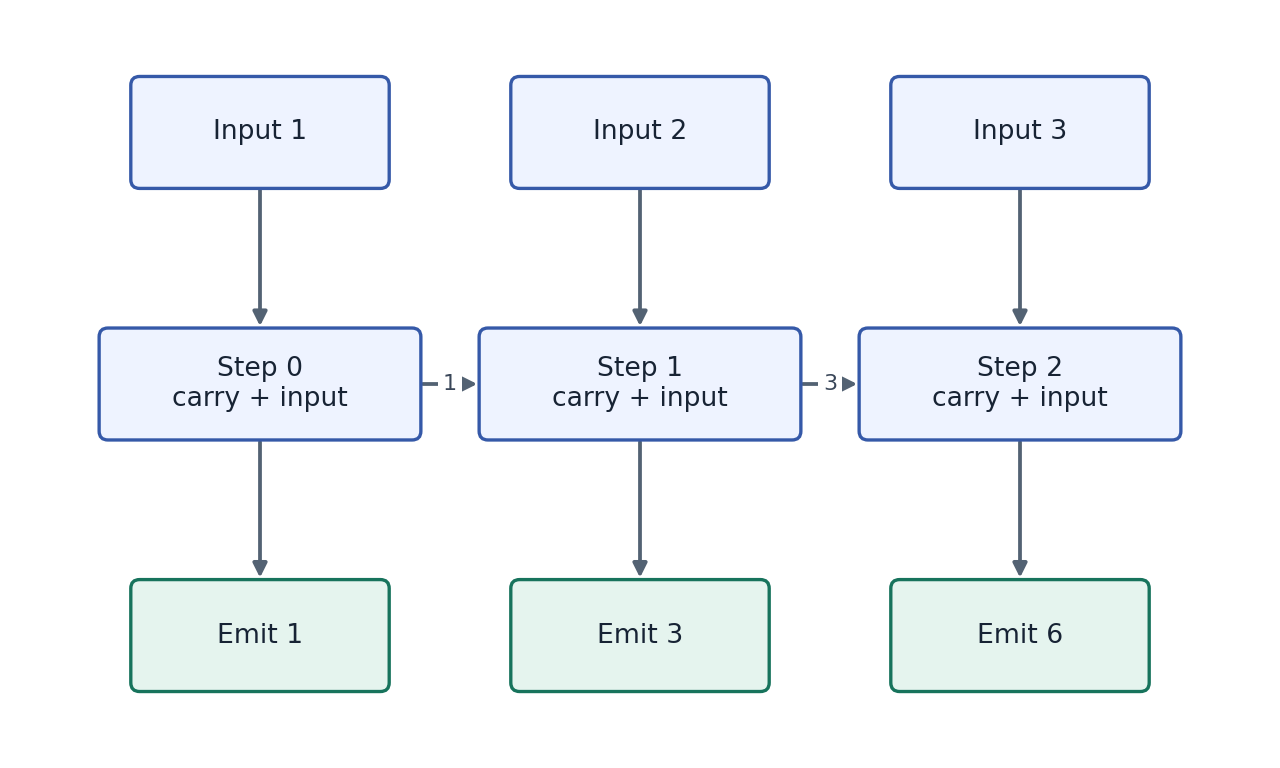

*Conceptual / analytic teaching diagram; not a recorded benchmark.*

An additive scan starts with carry $0$ and inputs $1,2,3$. Horizontal arrows pass updated carry; downward arrows collect emitted values. Final carry $6$ and outputs $[1,3,6]$ are different return values. Arrow lengths do not represent runtime.

### Pause and reason

What changes if the step emits the old carry instead of the new carry?

<details><summary>Compare your reasoning</summary>

The final carry is still $6$, but outputs become $[0,1,3]$. A final-state check alone would miss this off-by-one output convention.

</details>

## Separate carry from recorded outputs

Each scan step receives (carry,input) and returns (next_carry,output). Carry is what the next step needs. Output is what you want stacked into a history. They can have different meanings even when this demonstration returns the new state in both positions.

For decay $0.5$, initial state $0$ and four inputs of $1$, the states are $1$,$1.5$,$1.75$,$1.875$. There are four recorded outputs; the initial state is not automatically part of history. Decide whether a plot should include that initial point before labeling the time axis.

```text
(state_t, input_t) → transition → (state_(t+1), recorded_t)
state: 0 → 1 → 1.5 → 1.75 → 1.875
```

## Keep the carry contract invariant

Carry values change, but their pytree structure, shapes and dtypes must remain compatible across steps. Growing a Python list or concatenating a larger array into the carry changes that contract. Allocate a fixed-size state or use the separately stacked outputs instead.

This constraint is a representation decision, not an arbitrary restriction on simulation. A fixed-dimensional physical state naturally meets it. If a system has variable numbers of entities, consider padding and masks with an explicit maximum capacity.

## Differentiate the recurrence by hand

With four unit inputs and initial zero, the final value is $1+d+d^2+d^3$. Its derivative is $1+2d+3d^2$, giving $2.75$ at $d=0.5$. The derivative also obeys a recurrence: $s_{t+1}=\mathrm{state}_t+d s_t$, starting from $s_0=0$.

Autodiff through scan differentiates the represented state transition. It does not make an unstable or inaccurate numerical model valid. Verify a small analytic case first, then a changed input sequence, before trusting a longer simulation.

$$
\begin{aligned}s_{\mathrm{final}}(d)&=1+d+d^2+d^3\\\frac{ds_{\mathrm{final}}}{dd}&=1+2d+3d^2\\s_{\mathrm{final}}(0.5)&=1.875,\qquad s_{\mathrm{final}}\prime(0.5)=2.75\end{aligned}
$$

## Compile the repeated transition without a timing promise

A Python loop inside jit can be unrolled while tracing; scan expresses a repeated operation compactly. That can reduce compilation work for long loops, but it is not a universal promise that scan is faster for every workload.

Before benchmarking, compare numerical results on the same inputs and synchronize execution. Keep step count and precision explicit. For this lesson we verify correctness and derivatives; hardware profiling belongs to a later course unit.

## Prepare the inputs

Create main.py in your lesson workspace. Add this first block; use the environment from setup.

In [1]:
# Step 1 — Prepare the inputs: These explicit inputs define the case that the later checks will...
# Import jax for this computation.
import jax
import jax.numpy as jnp

These explicit inputs define the case that the later checks will verify.

## Build the computation

Append this block below the inputs in the same file.

In [2]:
# Step 2 — Build the computation: step returns the next scalar carry and one recorded scalar.
def step(carry, increment):
    # Evaluate `next_value` from the current inputs and state.
    next_value = 0.5 * carry + increment
    # Return `(next_value, next_value)` to the caller.
    return next_value, next_value
# Initialize array `increments` with explicit values and shape.
increments = jnp.array([1., 1., 1., 1.])

step returns the next scalar carry and one recorded scalar. scan feeds that carry back into step and stacks the four recorded outputs.

## Run and check the result

Append the checks, save main.py, and run python main.py from this folder using your course environment.

In [3]:
# Step 3 — Run and check the result: Compare the output to the expected result below before making the...
# Run compiled structured control flow via `jax.lax` (`(final, history)`).
final, history = jax.lax.scan(step, jnp.array(0.), increments)
# Print the observed values to compare against the expected result.
print("History:", history)
# Print diagnostic summary of the computed outputs.
print("Final:", float(final))
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(history, jnp.array([1.,1.5,1.75,1.875]))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(final, history[-1])

History: [1.    1.5   1.75  1.875]
Final: 1.875


Compare the output to the expected result below before making the exercise change.

## Run the example

In [4]:
# Step 1 — Prepare the inputs: These explicit inputs define the case that the later checks will...
# Import jax for this computation.
import jax
import jax.numpy as jnp
# Step 2 — Build the computation: step returns the next scalar carry and one recorded scalar.
def step(carry, increment):
    # Evaluate `next_value` from the current inputs and state.
    next_value = 0.5 * carry + increment
    # Return `(next_value, next_value)` to the caller.
    return next_value, next_value
# Initialize array `increments` with explicit values and shape.
increments = jnp.array([1., 1., 1., 1.])
# Step 3 — Run and check the result: Compare the output to the expected result below before making the...
# Run compiled structured control flow via `jax.lax` (`(final, history)`).
final, history = jax.lax.scan(step, jnp.array(0.), increments)
# Print the observed values to compare against the expected result.
print("History:", history)
# Print diagnostic summary of the computed outputs.
print("Final:", float(final))
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(history, jnp.array([1.,1.5,1.75,1.875]))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(final, history[-1])

History: [1.    1.5   1.75  1.875]
Final: 1.875


Expected: History: $[1., 1.5, 1.75, 1.875]$; Final: $1.875$.

## The carry approaches a fixed point

Predict: Why does the increment between successive states shrink?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: The carry approaches a fixed point
# Evaluate `visual_data` from the current inputs and state.
visual_data = {'kind': 'line', 'x': [1, 2, 3, 4], 'xlabel': 'completed step', 'ylabel': 'carry value', 'series': [{'label': 'scan history', 'y': history.tolist()}, {'label': 'fixed point 2', 'y': [2.0] * 4}]}

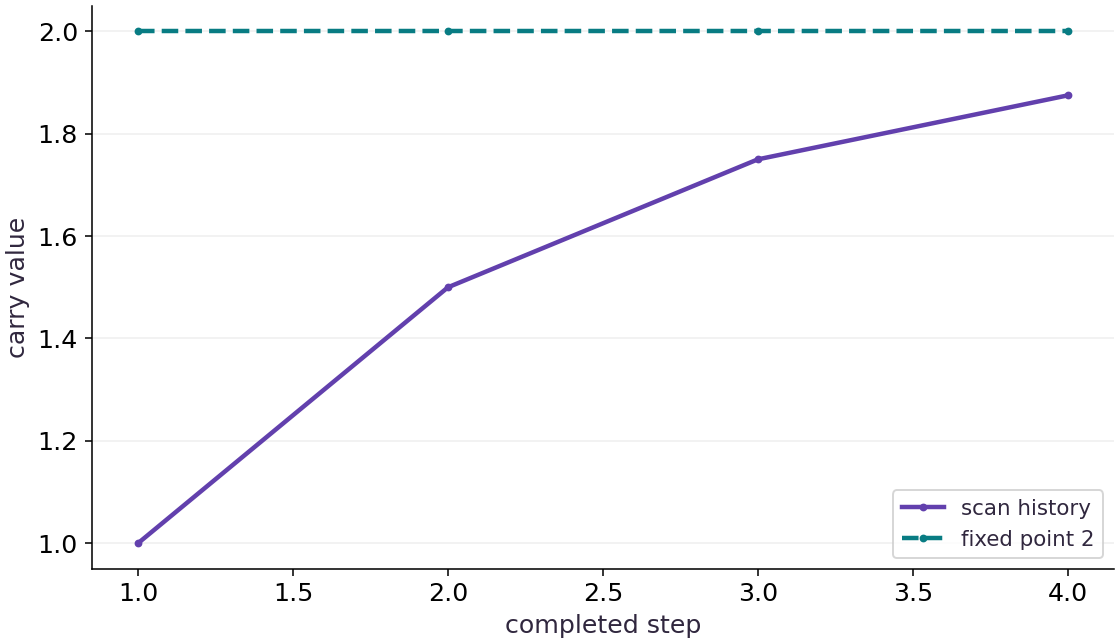

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The solid line shows the carry after each completed scan step. It starts at step $1$ with value $1$, then rises through $1.5$, $1.75$, and $1.875$. The dashed horizontal line marks the fixed point $2$.

The initial carry $0$ is not plotted. Each visible point is the value after applying the recurrence once more, so the first point already includes one update.

### Connect it to the computation

The update is $c_{t+1}=0.5c_t+1$. Subtracting it from the fixed point gives $2-c_{t+1}=0.5(2-c_t)$: each step halves the remaining gap. This explains both the upward movement and its slowing pace.

The shrinking gaps are $1$, $0.5$, $0.25$, and $0.125$. `scan` carries the evolving value forward while collecting this history. One more step would produce $1.9375$; it would not add another full unit or restart from the initial carry.

## Compare scan to the Python recurrence

Predict: Predict every output for inputs $[1,-1,2,0]$ and decay $0.5$.

In [7]:
# Experiment — Compare scan to the Python recurrence: The loop is an independent control-flow reference and the fixed...
# Initialize array `inputs` with explicit values and shape.
inputs=jnp.array([1.,-1.,2.,0.])
# Evaluate `state` from the current inputs and state.
state=0.
# Evaluate `reference` from the current inputs and state.
reference=[]
# Iterate over `inc` to step through the computation:
for inc in [1.,-1.,2.,0.]:
    # Evaluate `state` from the current inputs and state.
    state=0.5*state+inc
    # Append the current step result to `reference`.
    reference.append(state)
# Run compiled structured control flow via `jax.lax` (`(last, observed)`).
last,observed=jax.lax.scan(step,jnp.array(0.),inputs)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(observed,jnp.array([1.,-0.5,1.75,0.875]))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(observed,jnp.array(reference))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(last,state)

Expected: History $[1,-0.5,1.75,0.875]$; final $0.875$.

The loop is an independent control-flow reference and the fixed numbers verify time indexing.

## Verify state and sensitivity together

Predict: How do the state and derivative recurrences differ?

In [8]:
# Experiment — Verify state and sensitivity together: The scalar objective is the final state.
# Define `terminal(d)` to carry state across steps with `jax.lax.scan`:
def terminal(d):
    # Return `jax.lax.scan(lambda c, u: (d * c + u, d * c + u), jnp.array(0.0), increments)[0]` to the caller.
    return jax.lax.scan(lambda c,u:(d*c+u,d*c+u),jnp.array(0.),increments)[0]
# Differentiate the objective to obtain `(value, sensitivity)` via automatic differentiation.
value,sensitivity=jax.value_and_grad(terminal)(0.5)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(value,1.875)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(sensitivity,2.75)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jax.jit(terminal)(0.5),value)

Expected: Final state $1.875$ and sensitivity $2.75$.

The scalar objective is the final state. Returning the whole history to ordinary grad would need a deliberate scalar reduction.

## Your exercise

Make the decay an explicit scalar argument. Differentiate the final value with respect to decay and compare at $0.5$ with the analytic derivative $2.75$.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.grad(loss_fn)(params, ...)` — Transforms a scalar-output function into a function returning the gradient PyTree with the same structure as `params`.
- `jax.lax.scan(step_fn, init_carry, xs, length=...)` — Compiles a sequential loop where `step_fn(carry, x)` returns `(next_carry, y)`, returning `(final_carry, stacked_ys)`.

**Step-by-step implementation plan:**
1. Define `simulate(decay)` to carry state across steps with `jax.lax.scan`:
2. Function `transition(carry, increment)` implementing this stage's computation:
3. Evaluate `value` from the current inputs and state.
4. Return `(value, value)` to the caller.
5. Return `jax.lax.scan(transition, jnp.array(0.0), increments)[0]` to the caller.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Make the decay an explicit scalar argument.
# Define `simulate(decay)` to carry state across steps with `jax.lax.scan`:
def simulate(decay):
    # Function `transition(carry, increment)` implementing this stage's computation:
    def transition(carry, increment):
        # Evaluate `value` from the current inputs and state.
        value = ...  # TODO: compute value
        # Return `(value, value)` to the caller.
        return ...  # TODO: return computed result
    # Return `jax.lax.scan(transition, jnp.array(0.0), increments)[0]` to the caller.
    return ...  # TODO: return computed result
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(jax.grad(simulate)(0.5), 2.75)  # TODO: complete assertion check
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Make the decay an explicit scalar argument.
# Define `simulate(decay)` to carry state across steps with `jax.lax.scan`:
# def simulate(decay):
    # Function `transition(carry, increment)` implementing this stage's computation:
#     def transition(carry, increment):
        # Evaluate `value` from the current inputs and state.
#         value = ...  # TODO: compute value
        # Return `(value, value)` to the caller.
#         return ...  # TODO: return computed result
    # Return `jax.lax.scan(transition, jnp.array(0.0), increments)[0]` to the caller.
#     return ...  # TODO: return computed result
# Verify that the numerical values match the expected reference within tolerance.
# assert jnp.allclose(jax.grad(simulate)(0.5), 2.75)  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Make the decay an explicit scalar argument.
# Define `simulate(decay)` to carry state across steps with `jax.lax.scan`:
def simulate(decay):
    # Function `transition(carry, increment)` implementing this stage's computation:
    def transition(carry, increment):
        # Evaluate `value` from the current inputs and state.
        value = decay * carry + increment
        # Return `(value, value)` to the caller.
        return value, value
    # Return `jax.lax.scan(transition, jnp.array(0.0), increments)[0]` to the caller.
    return jax.lax.scan(transition, jnp.array(0.), increments)[0]
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(jax.grad(simulate)(0.5), 2.75)

## Record a different output · Practice

Carry the state, but record its squared value. Confirm that final carry still means state.

Hint: The second returned value is only the recorded output.

### How to write: Record a different output — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.lax.scan(step_fn, init_carry, xs, length=...)` — Compiles a sequential loop where `step_fn(carry, x)` returns `(next_carry, y)`, returning `(final_carry, stacked_ys)`.

**Step-by-step implementation plan:**
1. Run compiled structured control flow via `jax.lax` (`(last, energy)`).
2. Verify that the numerical values match the expected reference within tolerance.
3. Verify that the output satisfies the expected shape, finite-value, or numerical contract.

**Starter code scaffold (fill in the TODOs):**

```python
# Record a different output (Practice): Carry and history need not have the same interpretation.
# Run compiled structured control flow via `jax.lax` (`(last, energy)`).
last,energy = jax.lax.scan(...)  # TODO: compute last,energy
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(last,1.875)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(energy,jnp.array([1.,2.25,3.0625,3.515625]))  # TODO: complete assertion check
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Record a different output (Practice): Carry and history need not have the same interpretation.
# Run compiled structured control flow via `jax.lax` (`(last, energy)`).
# last,energy = jax.lax.scan(...)  # TODO: compute last,energy
# Verify that the numerical values match the expected reference within tolerance.
# assert jnp.allclose(last,1.875)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert jnp.allclose(energy,jnp.array([1.,2.25,3.0625,3.515625]))  # TODO: complete assertion check

## Reference reasoning

Carry and history need not have the same interpretation. The state remains unsquared for the next transition.

In [12]:
# Record a different output (Practice): Carry and history need not have the same interpretation.
# Run compiled structured control flow via `jax.lax` (`(last, energy)`).
last,energy=jax.lax.scan(lambda c,u:(0.5*c+u,(0.5*c+u)**2),jnp.array(0.),increments)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(last,1.875)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(energy,jnp.array([1.,2.25,3.0625,3.515625]))

## Diagnose a growing carry · Challenge

Try appending each input to the carry with concatenate. Explain why scan rejects it and replace it with stacked output.

Hint: The carry shape is part of the loop type.

### How to write: Diagnose a growing carry — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.zeros / jnp.ones(shape, dtype=...)` — Allocates a tensor of the given `shape` initialized with constants.
- `jax.lax.scan(step_fn, init_carry, xs, length=...)` — Compiles a sequential loop where `step_fn(carry, x)` returns `(next_carry, y)`, returning `(final_carry, stacked_ys)`.

**Step-by-step implementation plan:**
1. Return `(jnp.concatenate([c, u[None]]), u)` to the caller.
2. Run the boundary check and catch the expected exception:
3. Run compiled structured control flow via `jax.lax` (`(_, saved)`).
4. Verify contract: `jnp.array_equal(saved, increments)`.

**Starter code scaffold (fill in the TODOs):**

```python
# Diagnose a growing carry (Challenge): The error identifies incompatible carry input/output types.
def growing(c,u):
    # Return `(jnp.concatenate([c, u[None]]), u)` to the caller.
    return ...  # TODO: return computed result
# Run the boundary check and catch the expected exception:
try:
    jax.lax.scan(growing,jnp.zeros((0,)),increments)
except TypeError:
    print("Expected carry-shape mismatch")
else:
    raise AssertionError("Expected scan type failure")
# Run compiled structured control flow via `jax.lax` (`(_, saved)`).
_,saved = jax.lax.scan(...)  # TODO: compute _,saved
# Verify contract: `jnp.array_equal(saved, increments)`.
assert jnp.array_equal(saved,increments)  # TODO: complete assertion check
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Diagnose a growing carry (Challenge): The error identifies incompatible carry input/output types.
# def growing(c,u):
    # Return `(jnp.concatenate([c, u[None]]), u)` to the caller.
#     return ...  # TODO: return computed result
# Run the boundary check and catch the expected exception:
# try:
#     jax.lax.scan(growing,jnp.zeros((0,)),increments)
# except TypeError:
#     print("Expected carry-shape mismatch")
# else:
#     raise AssertionError("Expected scan type failure")
# Run compiled structured control flow via `jax.lax` (`(_, saved)`).
# _,saved = jax.lax.scan(...)  # TODO: compute _,saved
# Verify contract: `jnp.array_equal(saved, increments)`.
# assert jnp.array_equal(saved,increments)  # TODO: complete assertion check

## Reference reasoning

The error identifies incompatible carry input/output types. Store per-step values in scan outputs instead of growing the carry.

In [14]:
# Diagnose a growing carry (Challenge): The error identifies incompatible carry input/output types.
def growing(c,u):
    # Return `(jnp.concatenate([c, u[None]]), u)` to the caller.
    return jnp.concatenate([c,u[None]]),u
# Run the boundary check and catch the expected exception:
try:
    jax.lax.scan(growing,jnp.zeros((0,)),increments)
except TypeError:
    print("Expected carry-shape mismatch")
else:
    raise AssertionError("Expected scan type failure")
# Run compiled structured control flow via `jax.lax` (`(_, saved)`).
_,saved=jax.lax.scan(lambda c,u:(c,u),jnp.array(0.),increments)
# Verify contract: `jnp.array_equal(saved, increments)`.
assert jnp.array_equal(saved,increments)

Expected carry-shape mismatch


## Checkpoint

What must remain consistent across scan steps?

1. The numerical value of the carry
2. The carry structure, shapes, and dtypes
3. Every recorded output must be zero

## Diagnose

The error identifies incompatible carry input/output types. Store per-step values in scan outputs instead of growing the carry.

## Evidence

Keep the labeled carry/output transition, Python-reference trajectory, polynomial derivative, compiled value check and growing-carry failure with a fixed-shape repair.

## Carry forward

- The loop is an independent control-flow reference and the fixed numbers verify time indexing.
- The scalar objective is the final state. Returning the whole history to ordinary grad would need a deliberate scalar reduction.

## Primary references

- [JAX scan contract](https://docs.jax.dev/en/latest/_autosummary/jax.lax.scan.html)
- [JAX control flow](https://docs.jax.dev/en/latest/control-flow.html)